# Ride-segment terrain clustering

**Exploratory subproject — not part of the main app.**

The main app classifies every GPX point into `flat` / `climb` / `descent`
purely from local gradient (`|grade| <= 1.5%` -> flat, see
`../src/analysis.js`). That's a good rule for the app's cardio/strength
split, but it collapses a lot of real texture: a smooth open flat road and
a stop-start flat road through junctions both read as "flat".

This notebook asks: if we hand a clustering algorithm richer per-segment
features (gradient texture, speed variability, turn rate, stop-start
behaviour), what categories does the *data* actually support — and do any
of them look like genuinely new, useful categories (e.g. "flat with
obstacles", "rolling/punchy", "steady sustained climb")?

Data: every `.gpx` file in `../GPXExamples`.


In [1]:
# scikit-learn and torch each bundle their own OpenMP runtime (Intel vs
# LLVM); loading both in one process is a known source of crashes on
# macOS (see https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md).
# This env var must be set before numpy/sklearn/torch are imported.
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

%matplotlib inline
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=RuntimeWarning, module="threadpoolctl")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

import torch
import torch.nn as nn

from gpx_features import load_all_rides, WindowConfig

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
RNG = 42


## 1. Load all rides and engineer segment features

Each ride is sliced into non-overlapping 60-second windows. Each window gets a feature vector describing its terrain and riding texture (see `gpx_features.windowed_features` for exact definitions).

In [2]:
GPX_DIR = Path("../../GPXExamples")
combined, point_series = load_all_rides(GPX_DIR, WindowConfig(window_s=60))
print(combined.shape)
combined.head()


(2942, 27)


,ride,segment_idx,start_s,duration_s,distance_m,start_lat,start_lon,end_lat,end_lon,grade_mean,grade_std,grade_abs_mean,grade_sign_changes,elev_gain_m,elev_loss_m,speed_mean_kmh,speed_std_kmh,speed_cv,turn_rate_mean_dps,turn_rate_p90_dps,stop_fraction,hr_mean,hr_std,cad_mean,cad_std,power_mean,power_std
0,100% on Good Cycle Path - in UK!!!,0,0.0,59.0,256.953276,53.806114,-1.440575,53.807833,-1.438804,1.533566,1.056382,1.560836,4,4.016667,0.026667,15.417197,4.613487,0.299243,6.490385,17.305690,0.05,112.116667,6.651345,48.850000,20.260026,137.440678,79.873881
1,100% on Good Cycle Path - in UK!!!,1,60.0,59.0,413.764664,53.807853,-1.438720,53.807406,-1.432560,-0.628859,1.414193,1.114960,2,0.973333,3.880000,25.182695,2.513184,0.099798,3.606961,8.423556,0.00,129.216667,3.836010,61.150000,27.046617,144.616667,109.886242
2,100% on Good Cycle Path - in UK!!!,2,120.0,59.0,506.240552,53.807398,-1.432444,53.805332,-1.425793,-0.817124,0.763607,0.870583,3,0.120000,4.373333,30.834538,2.629482,0.085277,2.503213,5.681815,0.00,141.316667,2.135191,77.350000,15.556159,180.783333,63.186324
3,100% on Good Cycle Path - in UK!!!,3,180.0,59.0,406.914974,53.805301,-1.425669,53.804638,-1.419737,3.443893,4.203401,4.667839,2,12.853333,3.413333,24.945414,7.361240,0.295094,2.125962,4.893022,0.00,146.833333,3.599278,71.850000,9.642464,286.883333,119.904636
4,100% on Good Cycle Path - in UK!!!,4,240.0,59.0,323.976674,53.804608,-1.419680,53.802020,-1.421381,1.436427,1.752507,1.852437,3,5.040000,0.746667,19.739423,1.705910,0.086421,3.284637,8.413209,0.00,157.416667,1.062323,58.733333,23.901540,199.733333,98.488727


## 2. Rides and segment counts

In [3]:
summary = (
    combined.groupby("ride")
    .agg(
        segments=("segment_idx", "count"),
        distance_km=("distance_m", lambda s: s.sum() / 1000),
        duration_min=("duration_s", lambda s: s.sum() / 60),
        avg_grade_abs=("grade_abs_mean", "mean"),
        avg_stop_fraction=("stop_fraction", "mean"),
    )
    .round(2)
    .sort_values("distance_km", ascending=False)
)
summary


,segments,distance_km,duration_min,avg_grade_abs,avg_stop_fraction
ride,,,,,
L’Etape 2022,616,161.89,579.13,5.93,0.02
Tour of Flanders Sportive 2026,448,158.07,421.73,3.45,0.06
L’Etape 2023 Annemasse to Morzine,561,152.84,539.42,6.06,0.02
L’Etape 2024,584,142.18,560.78,5.71,0.02
Ronde van Elmet Cyclepaths - well 98%,134,49.03,129.27,1.85,0.03
Gvc Tuesday,96,41.66,91.58,1.75,0.01
Zwift - Group Ride: Stage 4 - Tour Fever - L'Etape du Tour de France Femmes,149,32.49,146.43,7.84,0.00
Afternoon Ride,82,31.85,78.58,1.84,0.02
Lunch Ride,78,30.73,71.72,2.28,0.02


## 3. Feature distributions

A quick look at the spread of the core engineered features across all segments, all rides pooled.

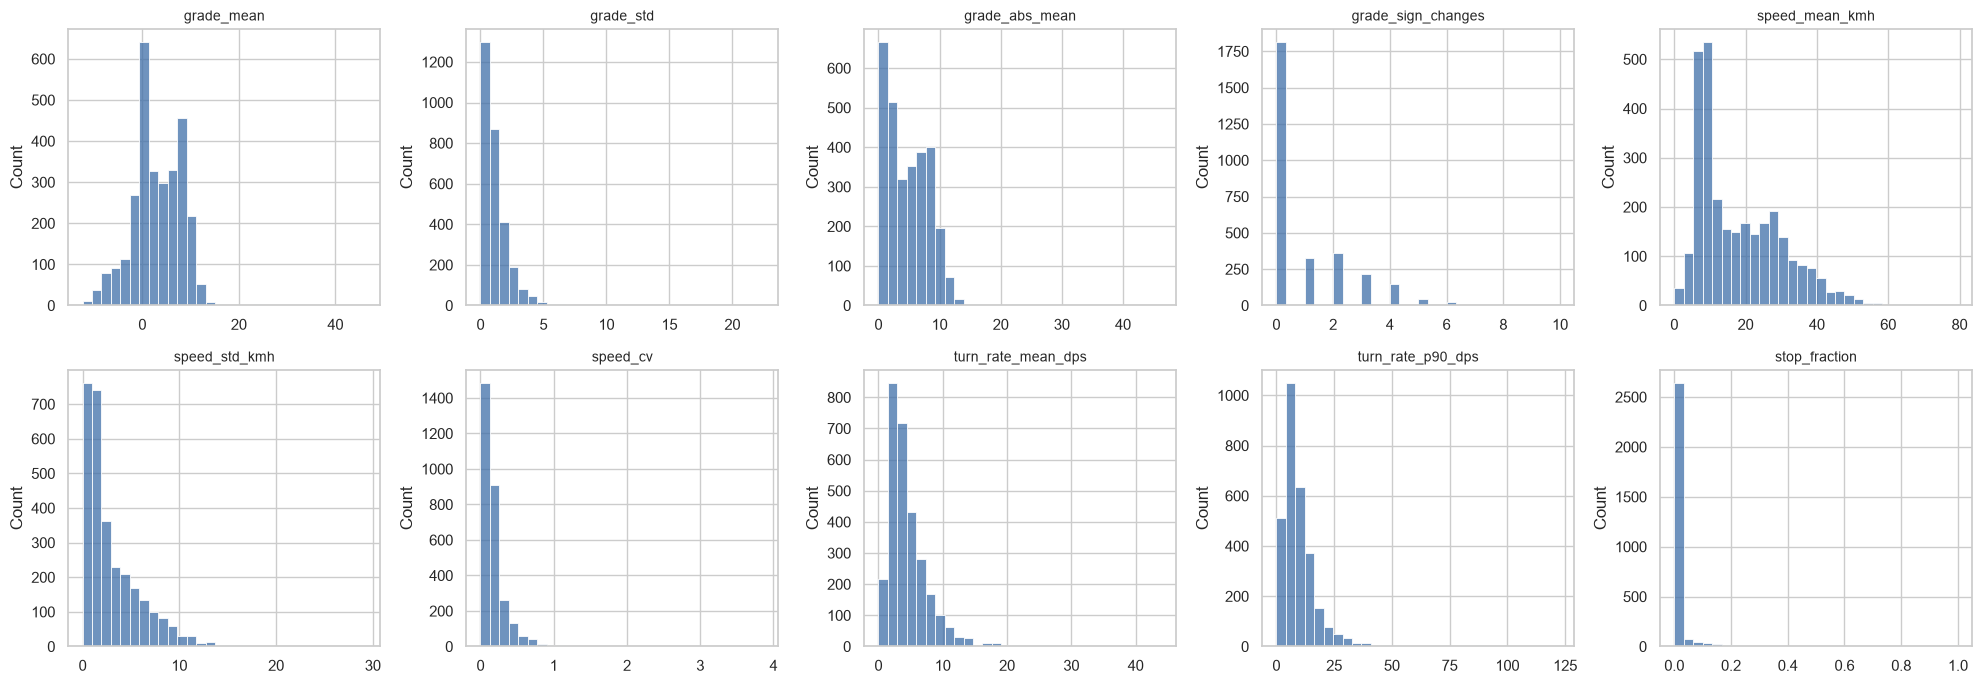

In [4]:
CORE_FEATURES = [
    "grade_mean", "grade_std", "grade_abs_mean", "grade_sign_changes",
    "speed_mean_kmh", "speed_std_kmh", "speed_cv",
    "turn_rate_mean_dps", "turn_rate_p90_dps", "stop_fraction",
]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.ravel(), CORE_FEATURES):
    sns.histplot(combined[col], bins=30, ax=ax, color="#3f6fa8")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
fig.tight_layout()


## 4. Correlation between features

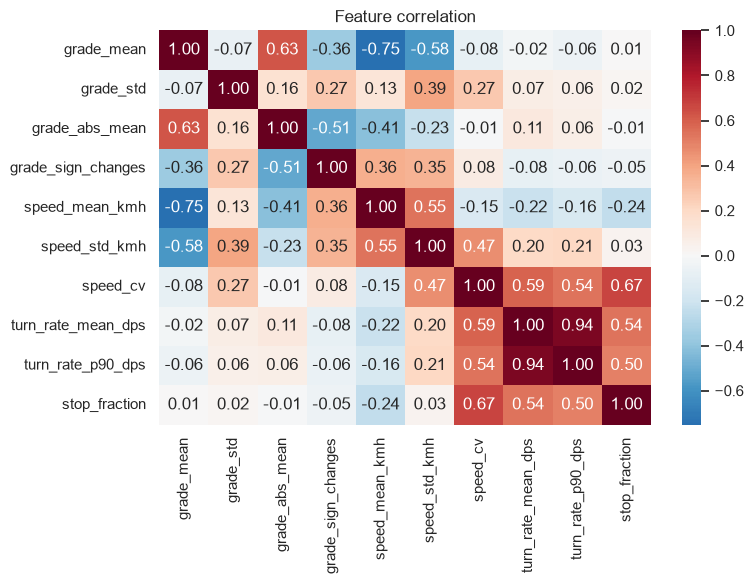

In [5]:
corr = combined[CORE_FEATURES].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Feature correlation")
fig.tight_layout()


## 5. Standardise features for clustering

`CORE_FEATURES` above are used for clustering because every ride has
them — heart rate/cadence/power are missing for some rides/segments (e.g.
the walk has no cadence, some rides have no power meter), so they're kept
aside for validating clusters afterwards rather than driving the
clustering itself.

Segment *counts* are heavily imbalanced across rides now that several
multi-hour mountain sportives are in the set — the three L'Etape rides
alone are ~60% of all 2,942 segments. Fitting the scaler/clusterer on the
raw pooled segments would make every downstream step (`best_k`,
centroids) mostly describe Alpine climbing texture rather than "what
terrain textures exist across this whole set". So scaling and clustering
below are fit on a per-ride-capped sample; every segment (including the
uncapped rest) is then labelled by transforming/predicting through that
fitted scaler/model.


In [6]:
MAX_SEGMENTS_PER_RIDE = 150

fit_sample = (
    combined.groupby("ride", group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), MAX_SEGMENTS_PER_RIDE), random_state=RNG))
)
print("segments used to fit scaler/clusterer:", fit_sample.shape[0], "of", combined.shape[0])

scaler = StandardScaler()
X_fit_scaled = scaler.fit_transform(fit_sample[CORE_FEATURES].to_numpy())
X_scaled = scaler.transform(combined[CORE_FEATURES].to_numpy())
X_scaled.shape


segments used to fit scaler/clusterer: 1333 of 2942


(2942, 10)

## 6. PCA — a 2D look at the feature space

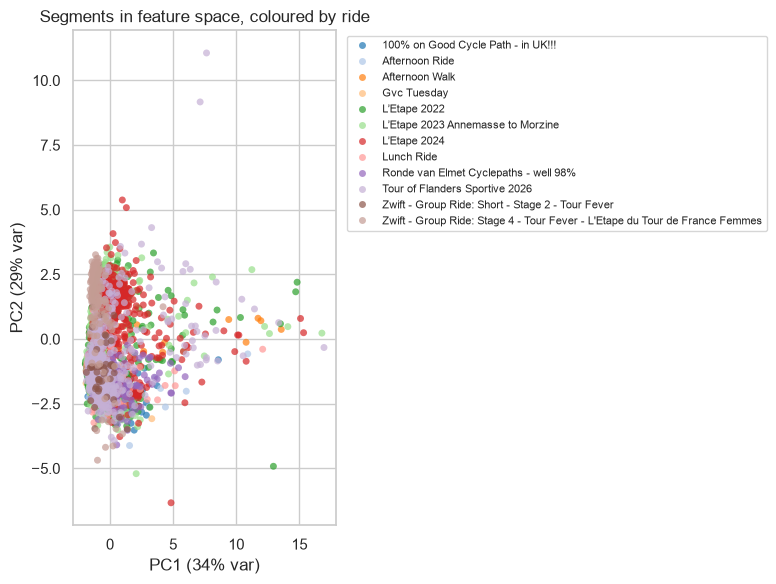

In [7]:
pca = PCA(n_components=2, random_state=RNG)
X_pca = pca.fit_transform(X_scaled)

# tab10 only has 10 distinct hues; this set now has 12 rides, so a fixed
# "tab10" string would silently repeat colours across two rides.
ride_palette = sns.color_palette("tab20", combined["ride"].nunique())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=combined["ride"], ax=ax,
    palette=ride_palette, s=25, alpha=0.7, linewidth=0,
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
ax.set_title("Segments in feature space, coloured by ride")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()


## 7. Choosing k for KMeans (elbow + silhouette)

Sweeping k rather than assuming a number of categories up front — the whole point is to let the data say how many distinct terrain textures there are.

best_k by silhouette (fit on the per-ride-capped sample): 3


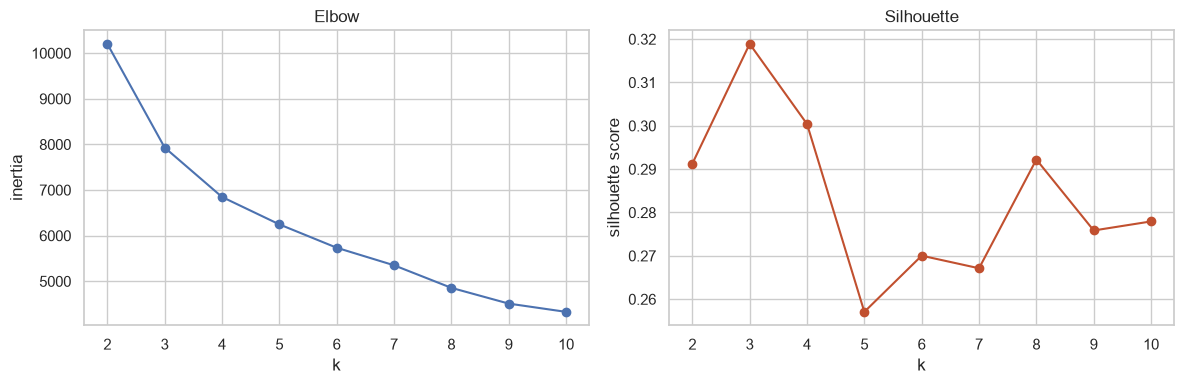

In [8]:
k_range = range(2, 11)
inertias = []
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG)
    labels = km.fit_predict(X_fit_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_fit_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, "o-")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow")
axes[1].plot(list(k_range), silhouettes, "o-", color="#c1502f")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette")
fig.tight_layout()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print("best_k by silhouette (fit on the per-ride-capped sample):", best_k)


## 8. Fit KMeans with the chosen k and inspect cluster centroids

In [9]:
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RNG)
kmeans.fit(X_fit_scaled)
combined["cluster"] = kmeans.predict(X_scaled)  # label every segment, not just the capped fitting sample

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=CORE_FEATURES)
centroid_df["n_segments"] = combined["cluster"].value_counts().sort_index().values
centroid_df.round(2)


,grade_mean,grade_std,grade_abs_mean,grade_sign_changes,speed_mean_kmh,speed_std_kmh,speed_cv,turn_rate_mean_dps,turn_rate_p90_dps,stop_fraction,n_segments
0,-0.46,1.39,2.10,2.07,27.05,4.66,0.19,4.08,8.82,0.01,1388
1,6.75,0.96,6.96,0.10,9.70,1.18,0.12,3.69,7.52,0.00,1409
2,2.74,1.46,4.04,0.90,8.00,5.35,0.77,14.87,34.67,0.37,145


## 9. Hand-labelling clusters from their centroid profile

A simple, transparent rule-based labeller over the *centroid* values (not
the raw data) — it turns each cluster's characteristic shape into a
human-readable name. Treat these labels as a first-pass starting point to
refine by eye against section 11's plots, not a final taxonomy.


In [10]:
def label_cluster(row, medians):
    grade = row["grade_abs_mean"]
    grade_signed = row["grade_mean"]
    turny = row["turn_rate_mean_dps"] > medians["turn_rate_mean_dps"]
    # A stop_fraction *cluster mean* of even ~0.1-0.2 is a lot (it's an
    # average over many windows, most of which have stop_fraction 0), so
    # this stays an absolute floor rather than "above the median" — with
    # only 3-4 clusters the median is a weak reference point.
    stoppy = row["stop_fraction"] > 0.1
    choppy = row["grade_sign_changes"] > medians["grade_sign_changes"]
    fast = row["speed_mean_kmh"] > medians["speed_mean_kmh"]
    # Obstacles/interruptions (junctions, hairpins, traffic) show up as
    # turniness or stopping *regardless* of whether the segment is flat or
    # climbing — a technical hairpin climb and a stop-start flat commute
    # share that texture even though their gradient differs completely.
    interrupted = turny or stoppy

    if grade < 1.0:
        return "Flat with obstacles" if interrupted else "Flat, steady"
    if grade_signed <= -1.5:
        if interrupted:
            return "Technical / interrupted descent"
        return "Fast descent" if fast else "Cautious descent"
    if grade_signed >= 1.5:
        if interrupted:
            return "Technical / interrupted climb"
        return "Rolling / punchy climbing" if choppy else "Sustained climb"
    return "Rolling terrain with obstacles" if interrupted else "Rolling terrain"

medians = centroid_df[CORE_FEATURES].median()
centroid_df["label"] = centroid_df.apply(label_cluster, axis=1, medians=medians)
label_map = centroid_df["label"].to_dict()
combined["cluster_label"] = combined["cluster"].map(label_map)

centroid_df[["label", "n_segments", "grade_mean", "grade_abs_mean",
             "grade_sign_changes", "speed_mean_kmh", "turn_rate_mean_dps",
             "stop_fraction"]].round(2)


,label,n_segments,grade_mean,grade_abs_mean,grade_sign_changes,speed_mean_kmh,turn_rate_mean_dps,stop_fraction
0,Rolling terrain,1388,-0.46,2.10,2.07,27.05,4.08,0.01
1,Sustained climb,1409,6.75,6.96,0.10,9.70,3.69,0.00
2,Technical / interrupted climb,145,2.74,4.04,0.90,8.00,14.87,0.37


In [11]:
combined["cluster_label"].value_counts()


cluster_label
Sustained climb                  1409
Rolling terrain                  1388
Technical / interrupted climb     145
Name: count, dtype: int64

### 9b. A finer-grained view for comparison

`best_k` is chosen purely by silhouette score, which — given this
particular GPX set is dominated by mountain sportives — tends to land on a
coarse split by climb intensity rather than by riding *texture*. Refitting
at a deliberately higher k shows whether finer categories (like the
"interrupted vs sustained" distinction the labeller above can already
express) are latent in the data even where they don't win on silhouette
alone. Not used elsewhere in the notebook — purely a sanity check to look
at before trusting `best_k`.


In [12]:
FINER_K = 6
km_fine = KMeans(n_clusters=FINER_K, n_init=10, random_state=RNG)
fine_labels = km_fine.fit_predict(X_fit_scaled)
fine_centroids = pd.DataFrame(scaler.inverse_transform(km_fine.cluster_centers_), columns=CORE_FEATURES)
fine_centroids["n_segments"] = pd.Series(fine_labels).value_counts().sort_index().values
fine_medians = fine_centroids[CORE_FEATURES].median()
fine_centroids["label"] = fine_centroids.apply(label_cluster, axis=1, medians=fine_medians)

fine_centroids[["label", "n_segments", "grade_mean", "grade_abs_mean",
                "grade_sign_changes", "speed_mean_kmh", "turn_rate_mean_dps",
                "stop_fraction"]].round(2).sort_values("n_segments", ascending=False)


,label,n_segments,grade_mean,grade_abs_mean,grade_sign_changes,speed_mean_kmh,turn_rate_mean_dps,stop_fraction
0,Sustained climb,436,7.75,7.75,0.04,9.13,3.88,0.00
1,Rolling terrain,373,0.06,1.90,0.79,24.23,2.90,0.00
3,Rolling terrain,286,-0.03,2.07,3.37,28.40,3.28,0.00
4,Rolling terrain with obstacles,204,-0.85,2.95,1.75,21.88,7.96,0.05
2,Technical / interrupted climb,30,1.85,3.12,0.60,5.02,16.97,0.54
5,Technical / interrupted climb,4,26.13,26.13,0.00,3.95,8.95,0.50


## 10. Cross-checking with a PyTorch autoencoder embedding

If a completely different, nonlinear representation of the same segments (learned by a small autoencoder) clusters similarly to the hand-crafted features above, that's evidence the categories are a real structure in the data rather than an artefact of which features we picked.

In [13]:
class Autoencoder(nn.Module):
    def __init__(self, in_dim, bottleneck=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 8), nn.ReLU(),
            nn.Linear(8, bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 8), nn.ReLU(),
            nn.Linear(8, in_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


torch.manual_seed(RNG)
X_t = torch.tensor(X_scaled, dtype=torch.float32)

model = Autoencoder(in_dim=X_t.shape[1], bottleneck=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

losses = []
for epoch in range(300):
    optimizer.zero_grad()
    recon, _ = model(X_t)
    loss = loss_fn(recon, X_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"final reconstruction MSE: {losses[-1]:.4f}")


final reconstruction MSE: 0.3606


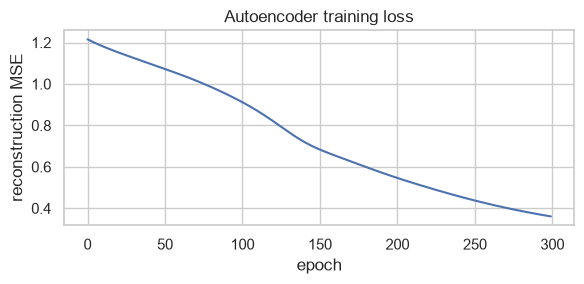

In [14]:
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("reconstruction MSE")
plt.title("Autoencoder training loss")
plt.tight_layout()


In [15]:
model.eval()
with torch.no_grad():
    _, embedding = model(X_t)
embedding = embedding.numpy()

km_embed = KMeans(n_clusters=best_k, n_init=10, random_state=RNG)
embed_labels = km_embed.fit_predict(embedding)

ari = adjusted_rand_score(combined["cluster"], embed_labels)
print(f"Adjusted Rand Index between feature-space and autoencoder-embedding clusterings: {ari:.3f}")
print("(1.0 = identical clustering, 0.0 = no better than random)")


Adjusted Rand Index between feature-space and autoencoder-embedding clusterings: 0.833
(1.0 = identical clustering, 0.0 = no better than random)


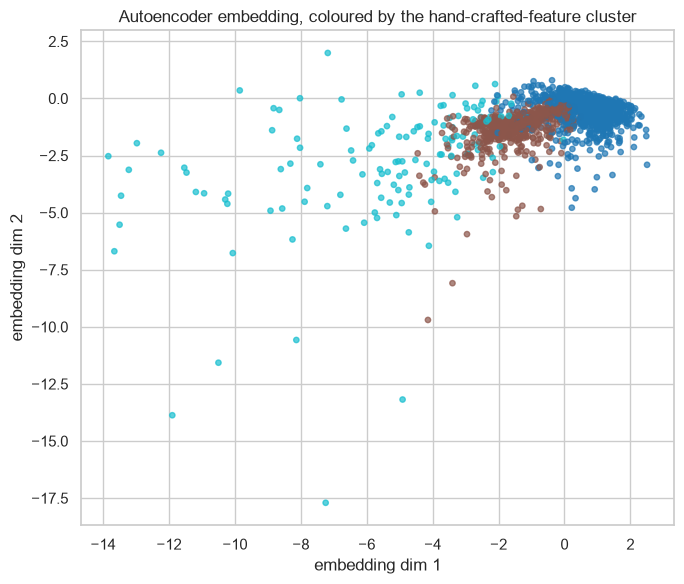

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=combined["cluster"], cmap="tab10", s=15, alpha=0.7)
ax.set_xlabel("embedding dim 1")
ax.set_ylabel("embedding dim 2")
ax.set_title("Autoencoder embedding, coloured by the hand-crafted-feature cluster")
fig.tight_layout()


## 11. Visual sanity check: elevation profile and route map by cluster

Picking four contrasting rides to see whether the clusters line up with
what the terrain actually looks like: the flattest and hilliest *outdoor*
rides by elevation gain per km, a Zwift ride checked separately, and the
ride with the widest spread of standardised feature values — i.e. the one
that itself mixes the most different textures (climbing, flat, technical),
rather than being dominated by one throughout — as the best single-ride
test of whether the clustering actually separates textures *within* a
ride, not just *between* rides.

Zwift's elevation is physics-simulated rather than GPS-derived, so its
gain-per-km figures run more extreme than any outdoor ride in the set —
picking flattest/hilliest from the pooled set lets Zwift take *both*
slots (confirmed by running this before splitting it out), leaving no
outdoor GPS ride checked at all. Splitting the pick guarantees a look at
both worlds.


In [17]:
is_zwift = combined["ride"].str.contains("Zwift")

outdoor_gain_per_km = combined[~is_zwift].groupby("ride").apply(
    lambda g: g["elev_gain_m"].sum() / (g["distance_m"].sum() / 1000)
)
flat_ride = outdoor_gain_per_km.idxmin()
hilly_ride = outdoor_gain_per_km.idxmax()

zwift_gain_per_km = combined[is_zwift].groupby("ride").apply(
    lambda g: g["elev_gain_m"].sum() / (g["distance_m"].sum() / 1000)
)
zwift_ride = zwift_gain_per_km.idxmax()  # the more eventful of the two Zwift rides

# Widest spread of standardised feature values -> the ride that itself
# mixes the most different textures, rather than being dominated by one
# throughout. Uses the same standardised features clustering runs on, so
# "variation" is comparable across features on very different raw scales
# (e.g. grade % vs speed km/h vs turn rate deg/s).
std_features = pd.DataFrame(X_scaled, columns=CORE_FEATURES, index=combined.index)
feature_variance = std_features.groupby(combined["ride"]).var().sum(axis=1)
already_picked = {flat_ride, hilly_ride, zwift_ride}
varied_ride = feature_variance.drop(index=already_picked, errors="ignore").idxmax()

print("flattest (outdoor):", flat_ride, round(outdoor_gain_per_km[flat_ride], 1), "m/km")
print("hilliest (outdoor):", hilly_ride, round(outdoor_gain_per_km[hilly_ride], 1), "m/km")
print("zwift check ride:", zwift_ride, round(zwift_gain_per_km[zwift_ride], 1), "m/km")
print("widest feature variation:", varied_ride, round(feature_variance[varied_ride], 1))


flattest (outdoor): Gvc Tuesday 7.7 m/km
hilliest (outdoor): L’Etape 2024 32.0 m/km
zwift check ride: Zwift - Group Ride: Stage 4 - Tour Fever - L'Etape du Tour de France Femmes 46.4 m/km
widest feature variation: Tour of Flanders Sportive 2026 15.1


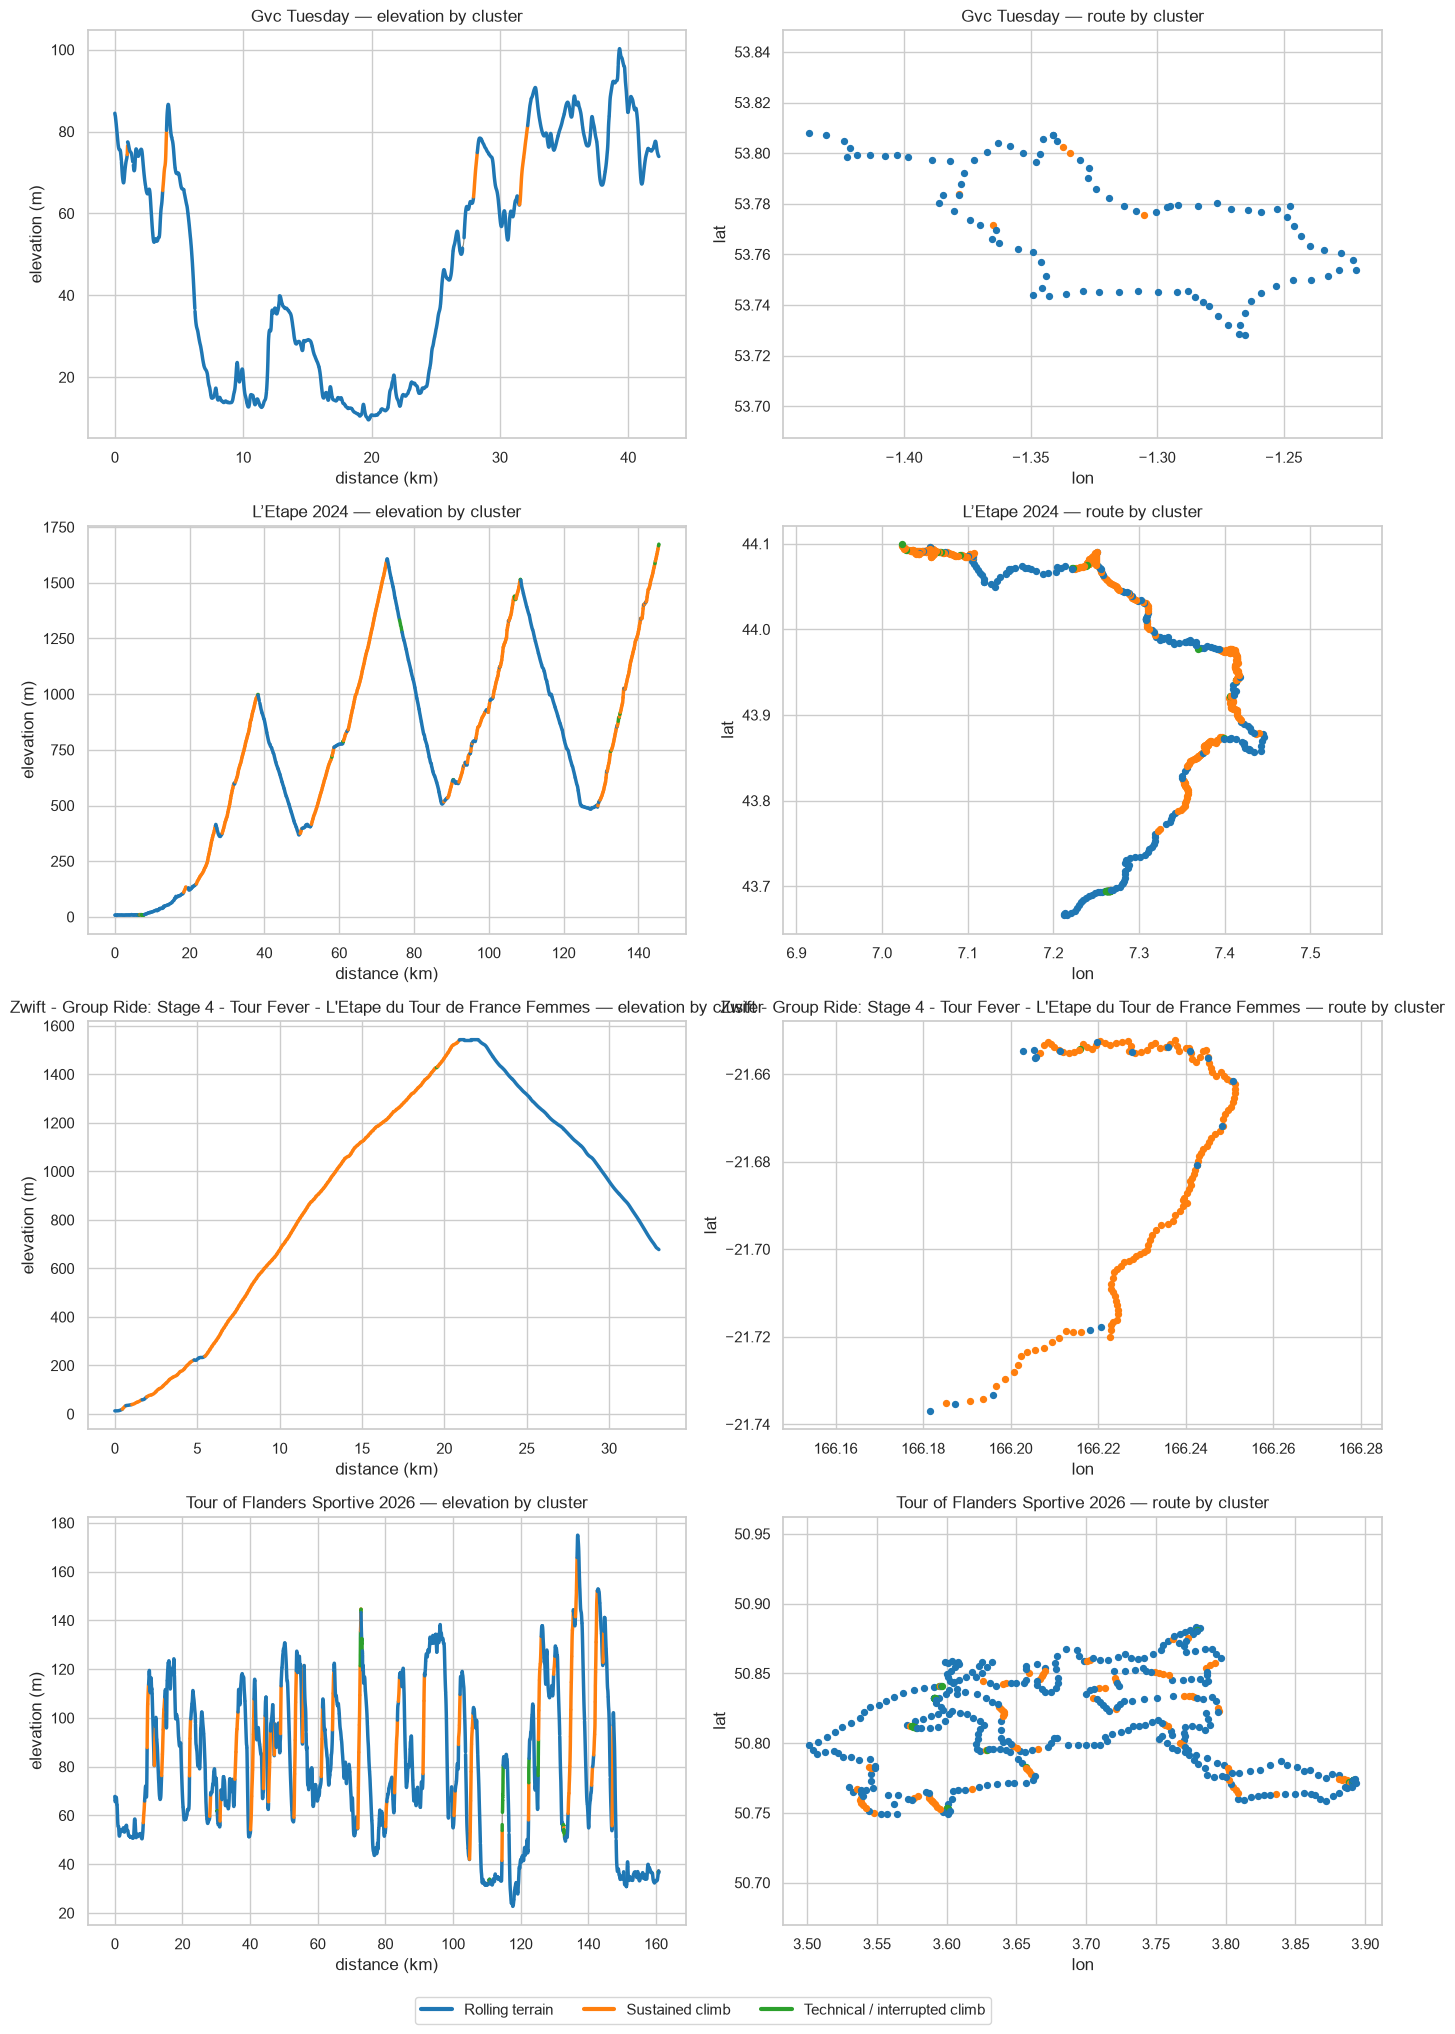

In [18]:
palette = dict(zip(sorted(combined["cluster_label"].unique()),
                    sns.color_palette("tab10", combined["cluster_label"].nunique())))

def plot_ride(ride_name, ax_elev, ax_map):
    seg = combined[combined["ride"] == ride_name].sort_values("segment_idx")
    pts = point_series[ride_name]

    ax_elev.plot(pts["dist_m"] / 1000, pts["smooth_ele"], color="#948f7f", linewidth=0.8, zorder=1)
    for _, row in seg.iterrows():
        d0 = row["start_s"]
        d1 = d0 + row["duration_s"]
        mask = (pts["t_s"] >= d0) & (pts["t_s"] <= d1)
        ax_elev.plot(pts.loc[mask, "dist_m"] / 1000, pts.loc[mask, "smooth_ele"],
                     color=palette[row["cluster_label"]], linewidth=2.5, zorder=2)
    ax_elev.set_title(f"{ride_name} — elevation by cluster")
    ax_elev.set_xlabel("distance (km)")
    ax_elev.set_ylabel("elevation (m)")

    for _, row in seg.iterrows():
        ax_map.scatter(row["start_lon"], row["start_lat"], color=palette[row["cluster_label"]], s=18)
    ax_map.set_title(f"{ride_name} — route by cluster")
    ax_map.set_xlabel("lon")
    ax_map.set_ylabel("lat")
    ax_map.set_aspect("equal", adjustable="datalim")


fig, axes = plt.subplots(4, 2, figsize=(14, 20))
plot_ride(flat_ride, axes[0, 0], axes[0, 1])
plot_ride(hilly_ride, axes[1, 0], axes[1, 1])
plot_ride(zwift_ride, axes[2, 0], axes[2, 1])
plot_ride(varied_ride, axes[3, 0], axes[3, 1])

handles = [plt.Line2D([0], [0], color=c, lw=3, label=l) for l, c in palette.items()]
fig.legend(handles=handles, loc="lower center", ncol=len(palette), bbox_to_anchor=(0.5, -0.02))
fig.tight_layout()


## 12. Save results

In [19]:
out_dir = Path("../output")
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "segment_clusters.csv"
combined.to_csv(out_path, index=False)
print("wrote", out_path.resolve(), combined.shape)


wrote /Users/kevinmayfield/github/kevinmayfield/MyPhysicalHealth/segment-analysis/output/segment_clusters.csv (2942, 29)


## Summary

Run this notebook top-to-bottom, then look at:

- Section 8/9's centroid table — the actual discovered categories and
  their defining feature values.
- Section 10's Adjusted Rand Index — how robust those categories are to
  a completely different (nonlinear, PyTorch-learned) representation.
- Section 11's plots — whether the categories visually make sense against
  real elevation profiles and routes.

If a genuinely new, useful category shows up consistently (e.g. "flat
with obstacles" as its own stable cluster, distinct from "flat, steady"),
that's a candidate for a follow-up: either a second classification pass
in the main app's pipeline, or a new highlight type in the report.
